# 3.3 多元线性回归

## 3.3.2 案例实战：客户价值预测模型

In [5]:
#读取数据
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第3章 线性回归模型\源代码汇总_PyCharm格式\客户价值数据表.xlsx")
df.head()

,客户价值,历史贷款金额,贷款次数,学历,月收入,性别
0,1150,6488,2,2,9567,1
1,1157,5194,4,2,10767,0
2,1163,7066,3,2,9317,0
3,983,3550,3,2,10517,0
4,1205,7847,3,3,11267,1


In [7]:
X = df[['历史贷款金额', '贷款次数', '学历', '月收入', '性别']]
Y = df['客户价值']

### 决策树回归模型

In [10]:
#模型搭建
from sklearn.tree import DecisionTreeRegressor

# 决策树回归模型搭建
dt_regr = DecisionTreeRegressor(random_state=42)
dt_regr.fit(X, Y)

DecisionTreeRegressor(random_state=42)

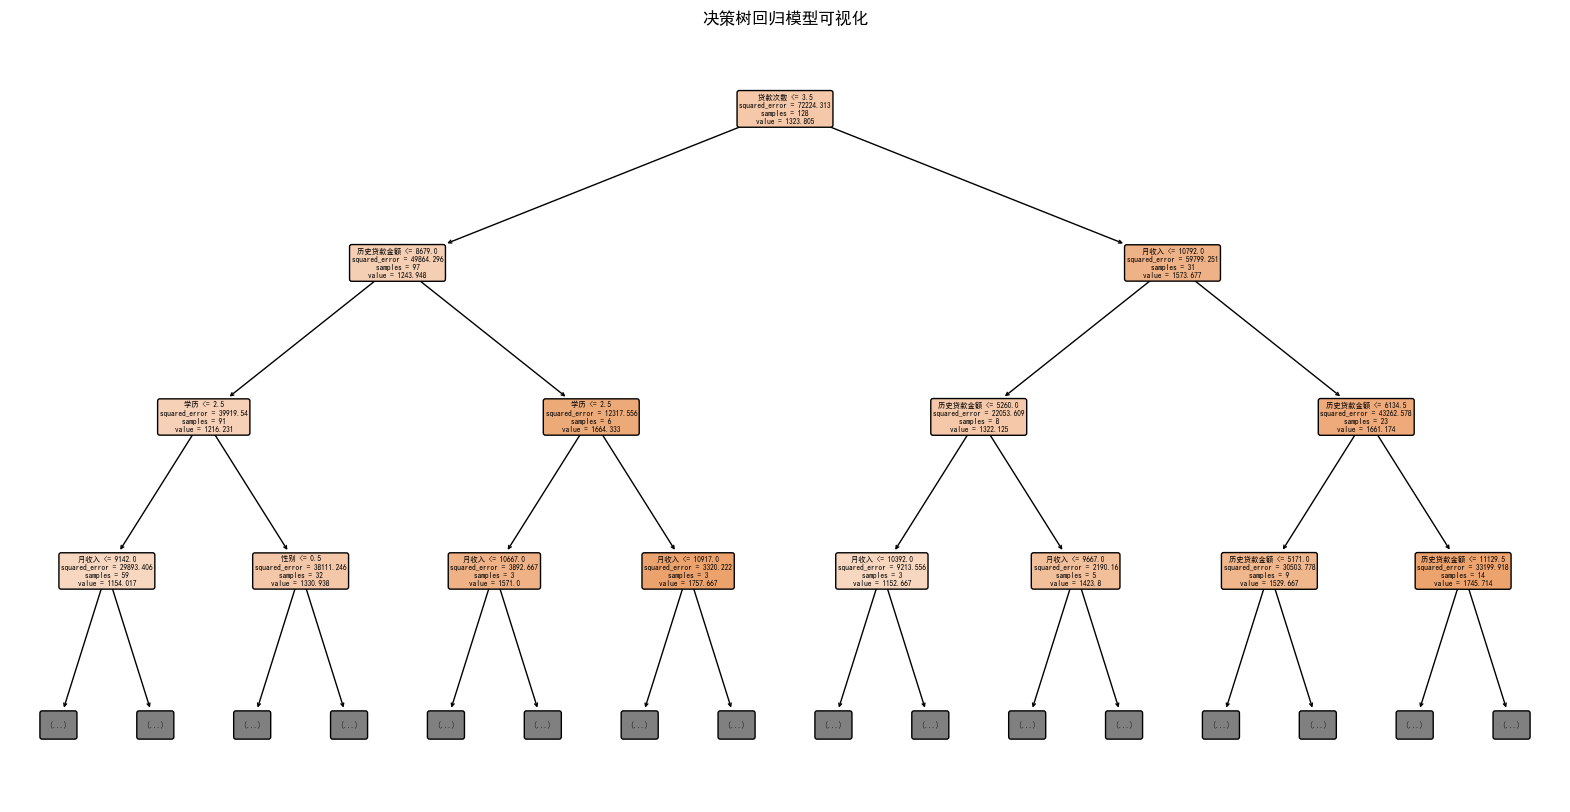

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 设置 matplotlib 的默认字体（解决字体缺失警告）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体（支持中文显示）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题

# 决策树可视化
plt.figure(figsize=(20,10))
plot_tree(dt_regr, 
          feature_names=['历史贷款金额', '贷款次数', '学历', '月收入', '性别'], 
          filled=True, 
          rounded=True, 
          max_depth=3)
plt.title('决策树回归模型可视化')
plt.show()


特征重要性为：[0.35320974 0.29397149 0.07682182 0.23338242 0.04261452]
模型得分：1.0


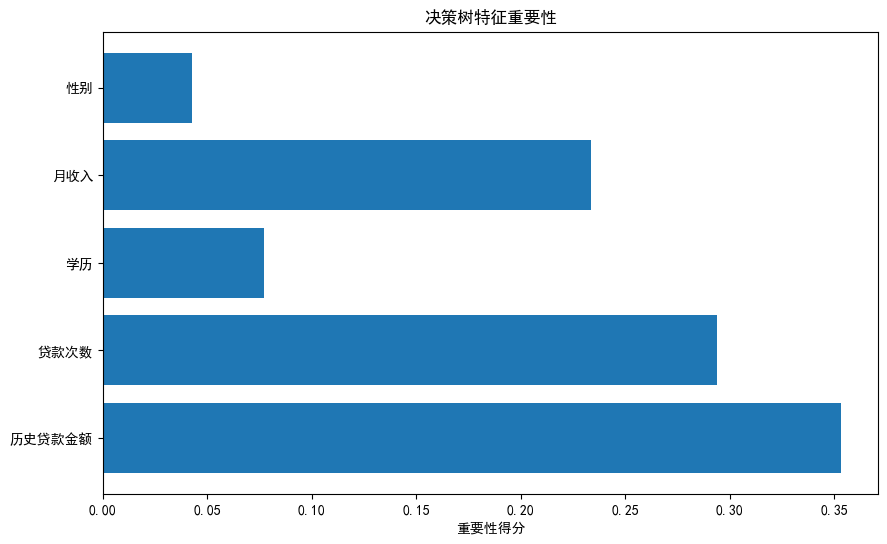

In [16]:
#模型评估与特征重要性
# 特征重要性（相当于线性回归的系数）
print('特征重要性为：' + str(dt_regr.feature_importances_))
print('模型得分：' + str(dt_regr.score(X, Y)))

# 特征重要性可视化
features = ['历史贷款金额','贷款次数','学历','月收入','性别']
importance = dt_regr.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title('决策树特征重要性')
plt.xlabel('重要性得分')
plt.show()

### 随机森林回归模型


In [19]:
#模型搭建
from sklearn.ensemble import RandomForestRegressor

# 随机森林回归模型搭建
rf_regr = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regr.fit(X, Y)

RandomForestRegressor(random_state=42)

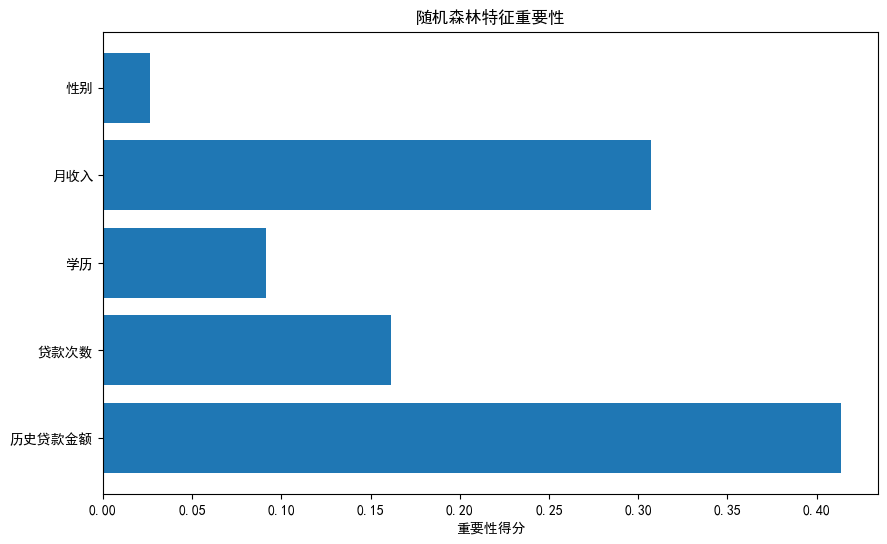

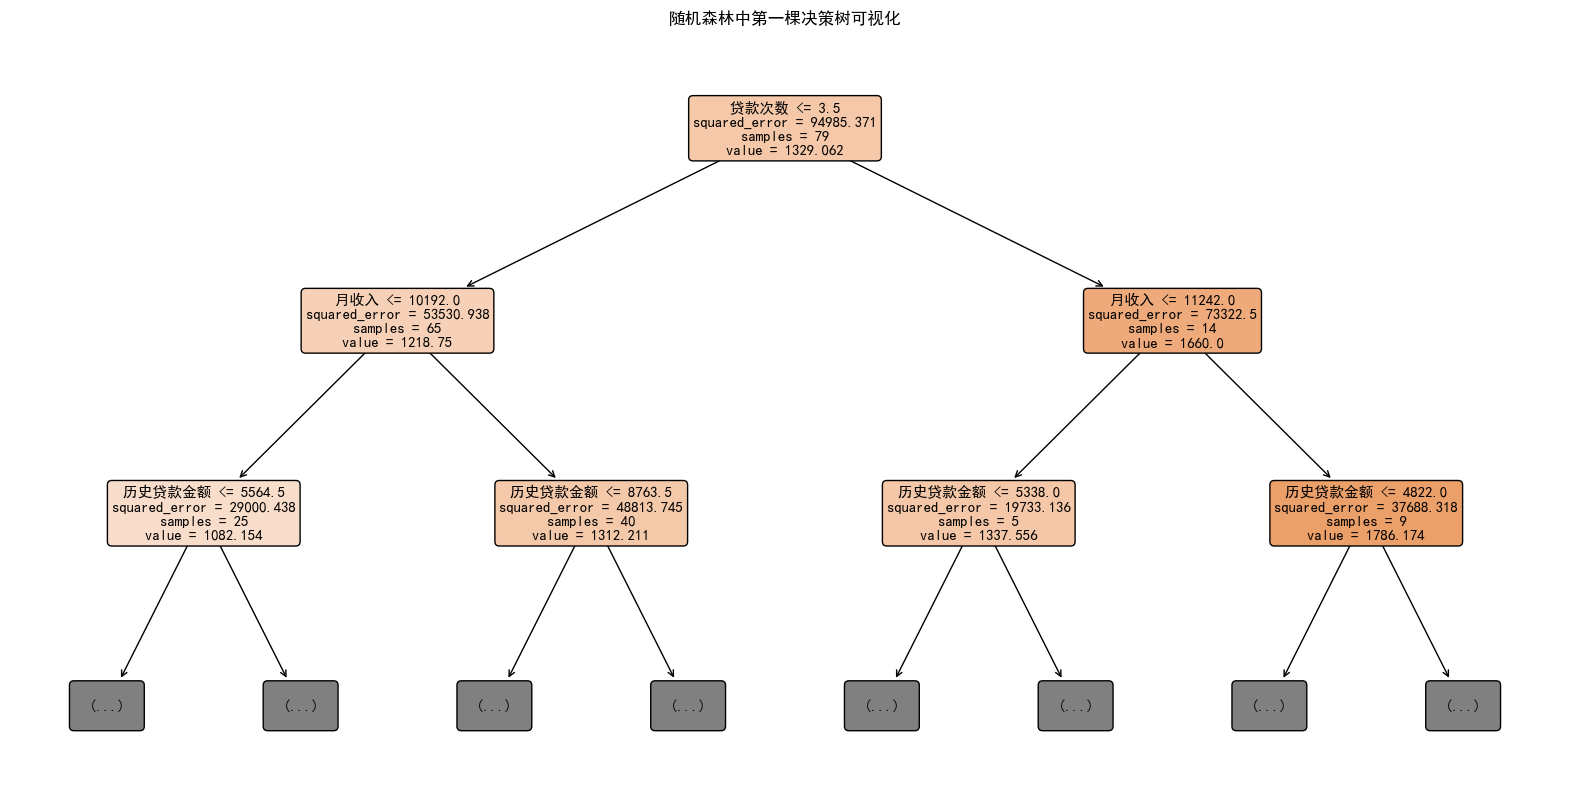

In [21]:
#模型可视化
# 随机森林特征重要性可视化
features = ['历史贷款金额','贷款次数','学历','月收入','性别']
importance = rf_regr.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title('随机森林特征重要性')
plt.xlabel('重要性得分')
plt.show()

# 单个决策树可视化（随机森林中的第一棵树）
plt.figure(figsize=(20,10))
plot_tree(rf_regr.estimators_[0], 
          feature_names=features,
          filled=True, 
          rounded=True,
          max_depth=2)
plt.title('随机森林中第一棵决策树可视化')
plt.show()

In [23]:
#模型评估
# 模型评估
print('特征重要性为：' + str(rf_regr.feature_importances_))
print('模型得分：' + str(rf_regr.score(X, Y)))
print('树木数量：' + str(len(rf_regr.estimators_)))

特征重要性为：[0.41366471 0.16168038 0.09158536 0.30689936 0.02617018]
模型得分：0.9134945600833597
树木数量：100


### 支持向量机回归模型

In [26]:
#模型搭建
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# 数据标准化（SVM对数据尺度敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 支持向量机回归模型搭建
svm_regr = SVR(kernel='rbf', C=1.0)
svm_regr.fit(X_scaled, Y)

SVR()

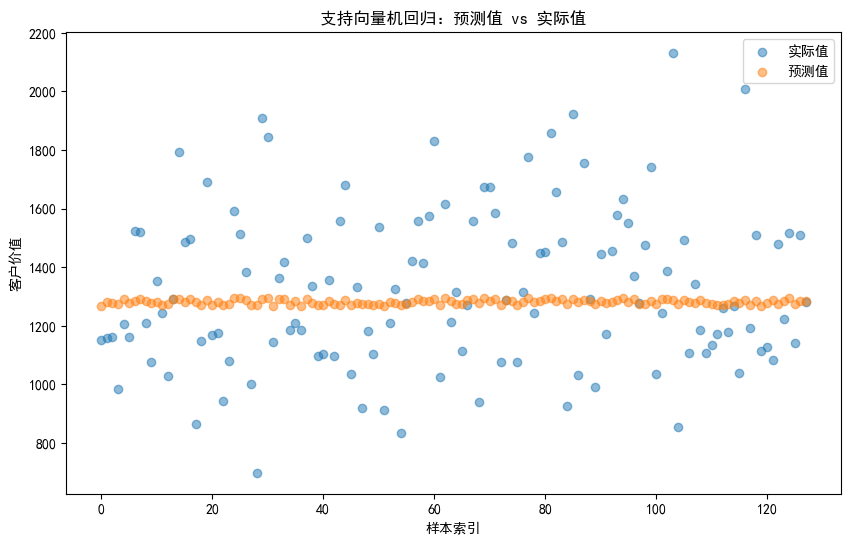

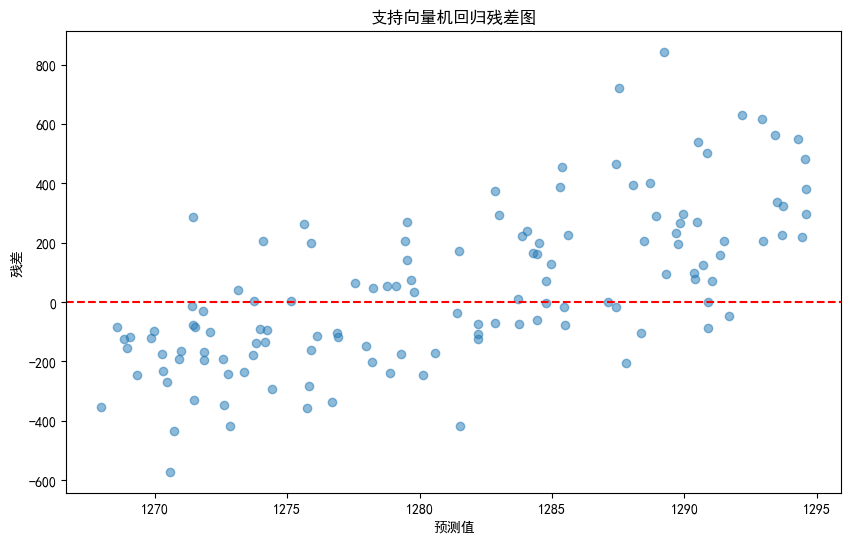

In [28]:
#模型可视化
import numpy as np

# 由于SVM在高维空间难以直接可视化，我们展示预测结果与实际值的对比
y_pred = svm_regr.predict(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(range(len(Y)), Y, alpha=0.5, label='实际值')
plt.scatter(range(len(y_pred)), y_pred, alpha=0.5, label='预测值')
plt.title('支持向量机回归：预测值 vs 实际值')
plt.xlabel('样本索引')
plt.ylabel('客户价值')
plt.legend()
plt.show()

# 残差图
residuals = Y - y_pred
plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('支持向量机回归残差图')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.show()

In [30]:
#模型评估
# 模型评估
print('模型得分：' + str(svm_regr.score(X_scaled, Y)))
print('支持向量数量：' + str(len(svm_regr.support_)))
print('支持向量索引：' + str(svm_regr.support_[:10]))  # 显示前10个支持向量索引

模型得分：0.015461742428016234
支持向量数量：128
支持向量索引：[0 1 2 3 4 5 6 7 8 9]
